# Contoh: Monitoring Efisiensi Energi Pabrik (Smart Factory)
Real-Time Energy Spike Detection

### Level 1: Domain Situation (Problem Statement)Situasi: 

- Manajer Operasional pabrik mengeluh tagihan listrik membengkak.
- Masalah: Ada mesin yang "bocor" energi (menyedot daya berlebih secara tiba-tiba), tapi sulit ditemukan karena ada 1.000 mesin yang berjalan bersamaan.
- Validasi: Wawancara manajer $\rightarrow$ "Saya butuh tahu mesin mana yang rusak dalam waktu kurang dari 1 menit agar bisa dimatikan."

Level 2: Data/Task Abstraction (The Translation)

- Di level ini, kita menerjemahkan "Mesin Bocor" menjadi bahasa teknis.
- Data: Time-series (Quantitative), Server ID (Nominal).
- Action: Search: Locate (Mencari mesin yang bermasalah).
- Target: Outliers (Lonjakan daya yang tidak wajar).
- Derive (Penting!): Kita harus menghitung "Z-Score" untuk menentukan apa itu "tidak wajar".

In [1]:
import pandas as pd
import numpy as np

# Simulasi data 1.000 mesin, masing-masing 1.000 log (1 Juta baris)
n_machines = 1000
n_logs = 1000
df = pd.DataFrame({
    'machine_id': np.repeat([f'M-{i}' for i in range(n_machines)], n_logs),
    'power_usage': np.random.normal(loc=50, scale=5, size=n_machines*n_logs)
})

df.head()

,machine_id,power_usage
0,M-0,48.817840
1,M-0,47.492560
2,M-0,45.187524
3,M-0,46.717701
4,M-0,48.700900


In [3]:
# LEVEL 2 VALIDATION: Menghasilkan data baru (Derive) untuk mendeteksi anomali
# Z-Score = (x - mean) / std

df['z_score'] = (df['power_usage'] - df['power_usage'].mean()) / df['power_usage'].std()
df['is_anomaly'] = df['z_score'] > 3  # Definisi teknis 'Outlier'

In [4]:
df.head()

,machine_id,power_usage,z_score,is_anomaly
0,M-0,48.817840,-0.238233,False
1,M-0,47.492560,-0.503025,False
2,M-0,45.187524,-0.963574,False
3,M-0,46.717701,-0.657843,False
4,M-0,48.700900,-0.261598,False


### Level 3: Visual Encoding/Interaction Idiom (The Design)
- Jika kita memplot 1 juta baris, manajer akan pusing (Overplotting). 
- Sesuai teori Munzner, kita harus menggunakan idiom yang efektif.
- Keputusan Desain: Jangan tampilkan semua data. Gunakan Overview + Detail. Tampilkan hanya mesin yang is_anomaly == True.

In [5]:
import plotly.express as px

# VALIDASI LEVEL 3: Menghindari Overplotting
# Hanya mengambil data yang dianggap anomali oleh Level 2
anomalies = df[df['is_anomaly'] == True]

# Menggunakan Scatterplot: X=Machine, Y=Power, Color=Severity
fig = px.scatter(anomalies, x='machine_id', y='power_usage', 
                 color='z_score', size='z_score',
                 title="Hanya Menampilkan Mesin yang Bermasalah (Locate Outliers)")
fig.show()

### Level 4: Algorithm (The Efficiency)
Manajer ingin data ini update cepat. Jika algoritma pengecekan anomali kita lambat, sistem akan hang.

In [6]:
import time

# VALIDASI LEVEL 4: Mengukur Kecepatan Algoritma
start = time.time()

# Cara A (Salah/Lambat): Menggunakan Loop Python
# for i in range(len(df)): 
#    if df['power_usage'][i] > 70: pass

# Cara B (Benar/Cepat): Vectorized Operations dengan Pandas/NumPy
anomalies_found = df[df['power_usage'] > 70]

end = time.time()
print(f"Level 4 Validated: Algoritma selesai dalam {end-start:.6f} detik")

Level 4 Validated: Algoritma selesai dalam 0.060875 detik


### Tugas 1

Tugas untuk Mahasiswa:
1. Modifikasi Level 2: Ubah kriteria anomali menjadi: "Mesin yang penggunaan dayanya naik 50% dibandingkan jam sebelumnya." (Ini memaksa mereka melakukan Action: Derive yang lebih kompleks). Lakukan analisis sehingga dapat mengahasilam informasi mesin yang sesuai dengan kriterima anomali

2. Modifikasi Level 4: Gunakan dataset 5 juta baris dan bandingkan waktu eksekusi antara df.apply() dengan df.vectorize(). Mana yang lebih valid untuk sistem real-time?

### Tugas 2

1. Validasi Level Domain (Perubahan Kebutuhan)
- Manajer berkata: "Titik lonjakan tunggal (satu detik saja) itu biasa karena mesin baru dinyalakan. Yang berbahaya adalah jika mesin menggunakan daya di atas rata-rata selama 10 menit berturut-turut."
- Soal: Jelaskan secara tertulis, mengapa definisi "Mesin Rusak" di versi awal kita gagal di Level Domain jika diterapkan pada skenario nya


2. Validasi Level Abstraction (Manipulasi Pandas)
- Karena aturan domain berubah, Anda harus mengubah Action: Derive di kode Anda.
- Soal Coding: Gunakan Rolling Average (rata-rata bergerak) di Pandas. Buat kolom baru bernama rolling_power yang menghitung rata-rata penggunaan daya per mesin dalam window 10 baris terakhir. Tentukan anomali berdasarkan nilai rolling_power ini, bukan lonjakan daya tunggal.

3. Validasi Level Idiom (Eksplorasi Desain)
- Manajer sekarang ingin melihat tren dari 5 mesin yang paling sering rusak, bukan sekadar titik scatter plot.
- Soal Coding & Analisis: Buatlah sebuah Line Chart (grafik garis) yang memplot data time-series dari 5 mesin dengan jumlah anomali terbanyak.
- Pertanyaan Justifikasi: Mengapa Line Chart lebih valid secara idiom visual untuk menampilkan "Tren dari waktu ke waktu" dibandingkan Scatter Plot?

4. Validasi Level Algorithm (Uji Stres Memori)
- Soal Coding: Lipat gandakan ukuran data menjadi 5 Juta baris (ubah n_logs = 5000 pada kode awal). Gunakan modul time untuk mengukur berapa detik waktu yang dibutuhkan untuk menjalankan operasi Rolling Average yang Anda buat di no 2. Tuliskan hasilnya di laporan!

# Studi Kasus Analisis Performa Maskapai Penerbangan (Flight Delay Analysis)
Evaluasi Kinerja Maskapai (4 Levels of Validation)

### Level 1: Domain Situation (Memahami Konteks Bisnis)
1. Siapa Penggunanya? Manajer Otoritas Bandara.

2. Masalah Nyata: Penumpang sering komplain karena penerbangan tertunda (delay). Manajer ingin mengevaluasi maskapai mana yang kinerjanya paling buruk pada hari-hari tertentu agar bisa memberikan teguran.

3. Metode Validasi (Teori): Anda tidak bisa menebak masalah ini. Anda harus mewawancarai staf bandara dan melihat buku komplain pelanggan. Jika ternyata keluhan utama penumpang adalah "bagasi hilang" dan bukan "delay", maka proyek visualisasi delay ini gagal di Level 1.

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time

# Membuat 500.000 data penerbangan sintetis
np.random.seed(42)
n_flights = 500000

df_flights = pd.DataFrame({
    'date': pd.date_range(start='2023-01-01', periods=n_flights, freq='min'),
    'airline': np.random.choice(['Garuda', 'Lion Air', 'Citilink', 'Batik Air', 'AirAsia'], n_flights),
    'day_of_week': np.random.choice(['Senin', 'Selasa', 'Rabu', 'Kamis', 'Jumat', 'Sabtu', 'Minggu'], n_flights),
    'delay_minutes': np.random.normal(loc=15, scale=30, size=n_flights)  # Ada yang minus (lebih cepat), ada yang plus (delay)
})

print("Level 1 Selesai: Dataset domain penerbangan berhasil dimuat.")

Level 1 Selesai: Dataset domain penerbangan berhasil dimuat.


In [9]:
df_flights.head()

,date,airline,day_of_week,delay_minutes
0,2023-01-01 00:00:00,Batik Air,Selasa,3.569751
1,2023-01-01 00:01:00,AirAsia,Sabtu,-25.140963
2,2023-01-01 00:02:00,Citilink,Rabu,28.231362
3,2023-01-01 00:03:00,AirAsia,Kamis,34.596087
4,2023-01-01 00:04:00,AirAsia,Kamis,-43.135669


### Level 2: Data/Task Abstraction (Menerjemahkan Masalah)
- Task Abstraction: Pengguna ingin membandingkan maskapai (Action: Compare) dan mencari siapa yang paling parah (Target: Extremes).

- Data Abstraction: Menit keterlambatan adalah data Kuantitatif. Namun, Manajer Bandara tidak peduli jika delay hanya 5 menit. Mereka peduli jika delay > 45 menit.

- Derive (Menghasilkan Data Baru): Kita harus mengubah data Kuantitatif (menit) menjadi data Ordinal (Status Keterlambatan).

- Metode Validasi (Teori): Anda menunjukkan aturan pengelompokan (kategori delay) kepada ahli penerbangan. Jika otoritas penerbangan bilang "Keterlambatan parah itu di atas 60 menit, bukan 45 menit", maka abstraksi Anda harus direvisi.

In [ ]:
# LEVEL 2 VALIDATION: Action Derive (Membuat atribut baru dengan pd.cut)
# Kita kelompokkan menit delay menjadi kategori yang bermakna secara bisnis

bins = [-np.inf, 15, 45, np.inf]
labels = ['On-Time', 'Minor Delay', 'Severe Delay']

df_flights['delay_status'] = pd.cut(df_flights['delay_minutes'], bins=bins, labels=labels)

# Kita hanya peduli pada persentase "Severe Delay"
# Derive tambahan: Menghitung persentase delay parah per maskapai per hari

df_severe = df_flights[df_flights['delay_status'] == 'Severe Delay']

# Menggunakan Pivot Table untuk menstruktur ulang data agar siap divisualisasikan
pivot_delay = pd.pivot_table(
    df_severe, 
    values='delay_minutes', 
    index='airline', 
    columns='day_of_week', 
    aggfunc='count'
)

# Normalisasi menjadi persentase (dibanding total penerbangan mereka)
total_flights = df_flights.groupby(['airline', 'day_of_week']).size().unstack()
delay_percentage = (pivot_delay / total_flights) * 100

print("Level 2 Selesai: Data berhasil diabstraksi menjadi 'Persentase Severe Delay'.")

Level 2 Selesai: Data berhasil diabstraksi menjadi 'Persentase Severe Delay'.


### Level 3: Visual Encoding/Idiom (Memilih Desain Terbaik)
- Keputusan Desain: Kita punya dua variabel kategorikal (Maskapai dan Hari) dan satu variabel kuantitatif (Persentase Delay). Idiom yang paling efektif untuk struktur ini adalah Heatmap.

- Visual Channel: Posisi (X dan Y) untuk kategori, dan Color Hue/Luminance untuk kuantitas.

- Metode Validasi (Teori): Menggunakan evaluasi heuristik. Mata manusia sangat cepat mendeteksi warna yang sangat gelap/terang (pop-out effect). Menggunakan tabel angka biasa akan membuat mata manajer kelelahan. Kita gunakan warna merah untuk mengasosiasikan "Bahaya/Buruk".

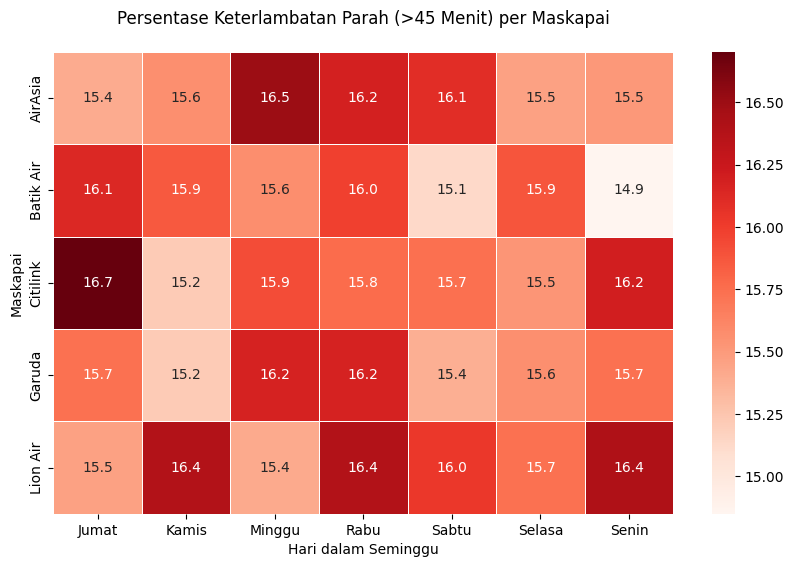

In [14]:
# LEVEL 3 VALIDATION: Menggunakan Heatmap untuk memfasilitasi "Compare Extremes"
plt.figure(figsize=(10, 6))

# Menggunakan colormap 'Reds' agar warna gelap otomatis diasosiasikan dengan delay tinggi
sns.heatmap(delay_percentage, annot=True, fmt=".1f", cmap="Reds", linewidths=.5)

plt.title("Persentase Keterlambatan Parah (>45 Menit) per Maskapai", pad=20)
plt.xlabel("Hari dalam Seminggu")
plt.ylabel("Maskapai")
plt.show()

# Validasi: Apakah grafik ini bisa menjawab "Maskapai apa yang paling parah di hari Jumat?" dalam waktu < 3 detik?

### Level 4: Algorithm (Menguji Efisiensi Komputasi)
- Fokus: Apakah proses perhitungan agregasi (groupby / pivot_table) pada 500.000 baris ini cukup cepat jika dijadikan dashboard interaktif?
- Metode Validasi (Teori): Analisis kompleksitas waktu $O(n)$ dan Benchmarking (pengukuran waktu eksekusi).

In [12]:
# LEVEL 4 VALIDATION: Benchmarking (Stress Test Komputasi)

start_time = time.time()

# Simulasi jika kita melakukan agregasi ulang setiap kali user menekan tombol "Refresh"
test_pivot = df_flights[df_flights['delay_status'] == 'Severe Delay'].groupby(['airline', 'day_of_week']).size()

end_time = time.time()
execution_time = end_time - start_time

print(f"Level 4 Validated: Proses agregasi 500.000 baris selesai dalam {execution_time:.4f} detik.")

# Jika waktu eksekusi < 1 detik, maka algoritma ini tervalidasi aman untuk dashboard real-time.

Level 4 Validated: Proses agregasi 500.000 baris selesai dalam 0.2620 detik.


### Tugas 3
Setelah mahasiswa menjalankan kode di atas, berikan mereka tugas evaluasi:

1. Evaluasi Level 1: Jika target user diubah dari "Manajer Bandara" menjadi "Penumpang Biasa", apakah Heatmap ini masih relevan? (Jawaban: Tidak. Penumpang lebih butuh visualisasi rute spesifik penerbangan mereka, bukan rata-rata mingguan).

2. Evaluasi Level 3: Coba ubah parameter warna di sns.heatmap menjadi cmap="rainbow". Mengapa penggunaan banyak warna (rainbow) dilarang dalam visualisasi data kuantitatif berurutan? (Jawaban: Karena mata manusia tidak secara alami mengurutkan warna pelangi sebagai "tinggi ke rendah").

### Tugas 4


1. Validasi Level Domain (Target User Berbeda)
- Bayangkan target pengguna Anda diubah dari "Manajer Bandara" menjadi "Calon Penumpang Biasa" yang sedang memesan tiket untuk liburan.- Soal: Tuliskan 2 pertanyaan wawancara (Level Domain) yang akan Anda tanyakan kepada calon penumpang untuk mengetahui kekhawatiran spesifik mereka terkait delay! (Apakah mereka peduli dengan agregasi mingguan seperti Manajer Bandara?)

2. Validasi Level Abstraction (Revisi Kategori)
- Kementerian Perhubungan mengeluarkan aturan baru:
    - Keterlambatan $< 30$ menit = "Bisa Ditoleransi"
    - Keterlambatan $30 - 90$ menit = "Kompensasi Makanan"
    - Keterlambatan $> 90$ menit = "Kompensasi Uang Tunai"
- Soal Coding: Ubah fungsi pd.cut() pada kode Anda untuk menyesuaikan rentang batas (bins) dan label ini. Hitung ada berapa penerbangan yang masuk kategori "Kompensasi Uang Tunai"!

3. Validasi Level Idiom (Heatmap vs Bar Chart)
- Soal Coding: Selain Heatmap, buatlah satu visualisasi alternatif menggunakan Grouped Bar Chart (Grafik Batang Berkelompok) di Plotly atau Seaborn untuk data yang sama.
- Soal Analisis: Letakkan kedua grafik berdampingan. Jika tugas (Task) penggunanya adalah "Bandingkan dengan cepat, maskapai mana yang paling buruk di hari Minggu" (Query: Compare), grafik mana yang lebih cepat membantu mata Anda menemukan jawabannya? Jelaskan alasannya berdasarkan teori persepsi (Marks & Channels).

4. Validasi Level Algorithm (Bad vs Good Code)
- Mari kita buktikan mengapa looping dilarang keras dalam pengolahan data besar.
- Soal Coding: Buat sebuah fungsi looping for tradisional (seperti iterrows) untuk menghitung total penerbangan yang delay di atas 90 menit. Bandingkan waktu eksekusinya dengan teknik vectorized filtering (misal: df[df['delay'] > 90]). Tuliskan perbandingan waktunya dalam hitungan detik.